In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image #load image files
from pathlib import Path #to work with file paths
import cv2

# Set visualization style
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette("husl")
%matplotlib inline

print("Starting IDRiD Data Exploration...")

Starting IDRiD Data Exploration...


In [3]:
# Define paths
BASE_PATH = Path('../data/raw/idrid')

print("Checking Data Directory:")
print(f"Base Path: {BASE_PATH.absolute()}")
print(f"Exists: {BASE_PATH.exists()}")

# List what is inside
if BASE_PATH.exists():
    print("\nContents:")
    for item in sorted(BASE_PATH.iterdir()):
        print(f"  {item.name}")

Checking Data Directory:
Base Path: /Users/shuverthi/Documents/Shuverthi/Capstone/dr-xai-project/notebooks/../data/raw/idrid
Exists: True

Contents:
  .DS_Store
  A. Segmentation
  B. Disease Grading
  C. Localization


In [4]:
# Find all images
def find_images(directory):
    extensions = ['.jpg', '.jpeg', '.png']
    images = []
    for ext in extensions:
        images.extend(list(directory.rglob(f'*{ext}')))
    return images

all_images = find_images(BASE_PATH)
print(f"Found {len(all_images)} total images")

# Show first 5
print("\nFirst 5 images:")
for img in all_images[:5]:
    print(f"  {img.relative_to(BASE_PATH)}")

Found 1113 total images

First 5 images:
  A. Segmentation/1. Original Images/a. Training Set/IDRiD_27.jpg
  A. Segmentation/1. Original Images/a. Training Set/IDRiD_33.jpg
  A. Segmentation/1. Original Images/a. Training Set/IDRiD_32.jpg
  A. Segmentation/1. Original Images/a. Training Set/IDRiD_26.jpg
  A. Segmentation/1. Original Images/a. Training Set/IDRiD_18.jpg


Sample Image: IDRiD_27.jpg
  Size: (4288, 2848)
  Mode: RGB


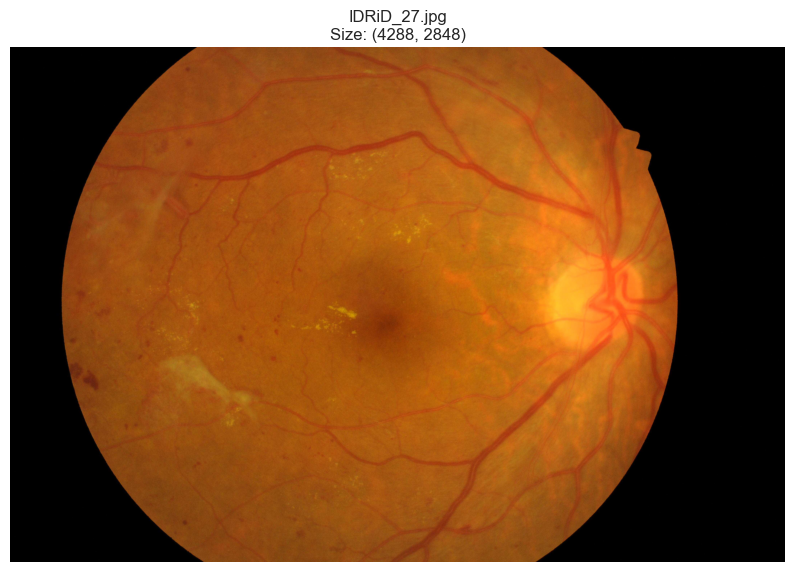

In [5]:
# Load and display one image
if len(all_images) > 0:
    sample_img = Image.open(all_images[0])
    
    print(f"Sample Image: {all_images[0].name}")
    print(f"  Size: {sample_img.size}")
    print(f"  Mode: {sample_img.mode}")
    
    plt.figure(figsize=(10, 8))
    plt.imshow(sample_img)
    plt.title(f"{all_images[0].name}\nSize: {sample_img.size}")
    plt.axis('off')
    plt.show()

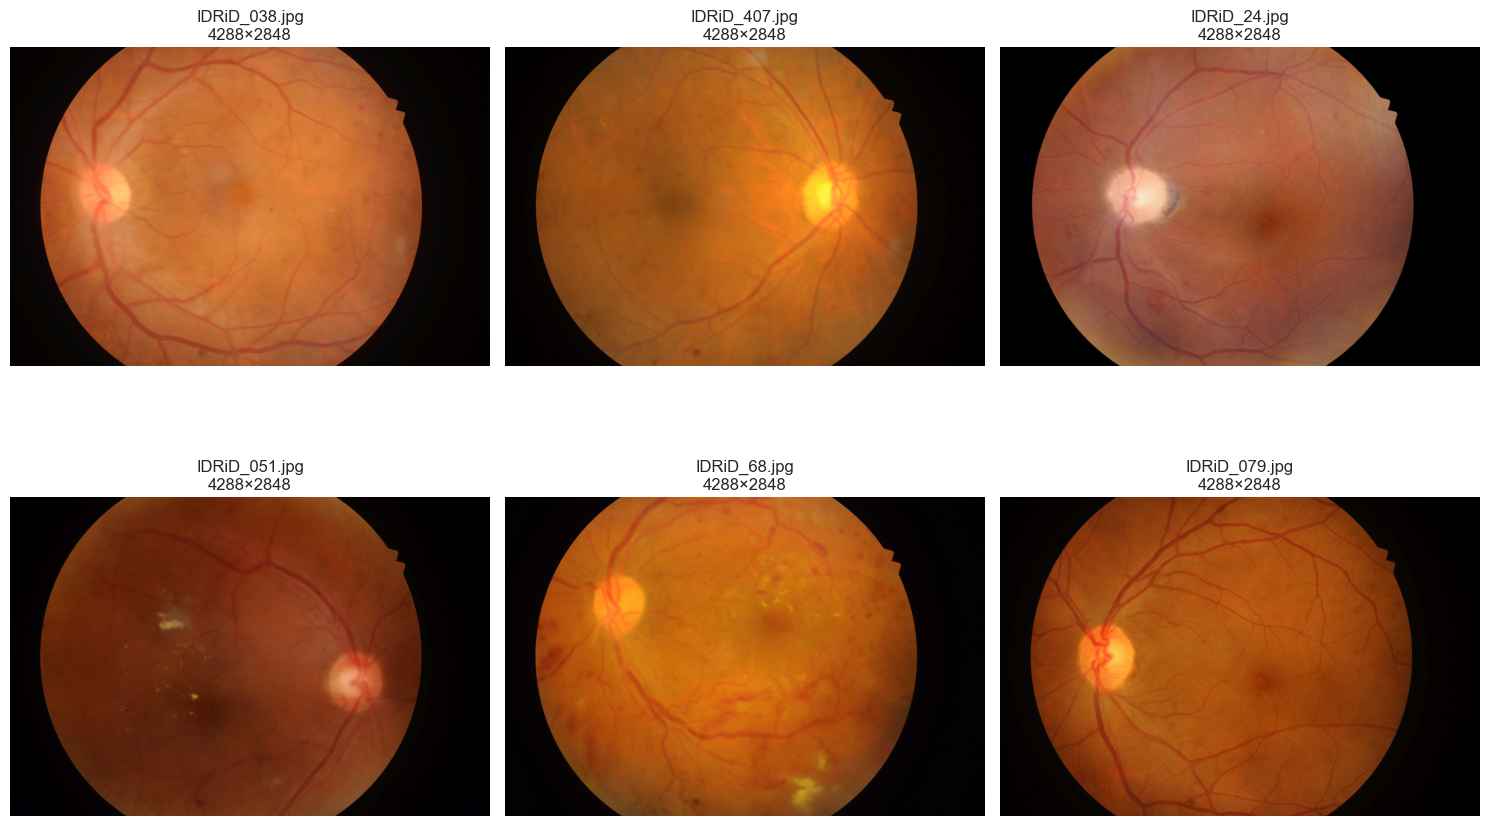

Displayed 6 sample fundus images!


In [6]:
# Display 6 random images
import random

if len(all_images) >= 6:
    sample_imgs = random.sample(all_images, 6)
    
    fig, axes = plt.subplots(2, 3, figsize=(15, 10))
    axes = axes.flatten()
    
    for idx, img_path in enumerate(sample_imgs):
        img = Image.open(img_path)
        axes[idx].imshow(img)
        axes[idx].set_title(f"{img_path.name}\n{img.size[0]}×{img.size[1]}")
        axes[idx].axis('off')
    
    plt.tight_layout()
    plt.show()
    
    print("Displayed 6 sample fundus images!")

In [7]:
# Analyze sizes
print("Analyzing Image Sizes")

sizes = []
for img_path in all_images[:50]:  # Sample 50 images
    img = Image.open(img_path)
    sizes.append(img.size)

widths = [s[0] for s in sizes]
heights = [s[1] for s in sizes]

print(f"\nAnalyzed {len(sizes)} images:")
print(f"  Width  - Min: {min(widths)}, Max: {max(widths)}, Mean: {int(np.mean(widths))}")
print(f"  Height - Min: {min(heights)}, Max: {max(heights)}, Mean: {int(np.mean(heights))}")

# Check if uniform
if len(set(sizes)) == 1:
    print(f"\n All images same size: {sizes[0]}")
else:
    print(f"\n Images have different sizes - will need resizing!")

Analyzing Image Sizes

Analyzed 50 images:
  Width  - Min: 4288, Max: 4288, Mean: 4288
  Height - Min: 2848, Max: 2848, Mean: 2848

 All images same size: (4288, 2848)


In [8]:
print("DATA EXPLORATION COMPLETE!")

print("\n Summary:")
print(f"  Total images: {len(all_images)}")
print(f"  Typical size: ~{int(np.mean(widths))}×{int(np.mean(heights))}")
print(f"  Format: Retinal fundus images")

DATA EXPLORATION COMPLETE!

 Summary:
  Total images: 1113
  Typical size: ~4288×2848
  Format: Retinal fundus images
